In [2]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, roc_auc_score, recall_score, cohen_kappa_score

In [4]:
import sklearn, numpy, pandas
print(sklearn.__version__)
print(numpy.__version__)
print(pandas.__version__)


1.3.2
1.24.3
2.3.0


## Load data

In [5]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


### Train-test split

In [6]:
X = df.drop(columns=['status'])
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [7]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2413})
After SMOTE:  Counter({0: 2828, 1: 2828})


# Logistic Regression

## Simple model

In [8]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sm, y_train_sm)

LogisticRegression(random_state=42)

In [9]:
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.770     0.738     0.754       707
           1      0.708     0.742     0.724       604

    accuracy                          0.740      1311
   macro avg      0.739     0.740     0.739      1311
weighted avg      0.741     0.740     0.740      1311



### Average Precision Score

In [10]:
y_probas = lr.predict_proba(X_test)[:, 1]
score = average_precision_score(y_test, y_probas)
print(f'Average Precision: {score:.3f}')

Average Precision: 0.761


### Hyperparameter Tuning

In [11]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('clf', LogisticRegression(max_iter=1000, solver='saga', random_state=42))
])

param_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.01, 0.1, 1, 10],
    },
    {
        'clf__penalty': ['l1'],
        'clf__C': [0.01, 0.1, 1, 10],
    },
    {
        'clf__penalty': ['elasticnet'],
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__l1_ratio': [0.1, 0.5, 0.9]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False,
                                                           interaction_only=True)),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2']},
                         {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1']},
                         {'clf__C': [0.01, 0.1, 1, 10],
                          'clf__l1_ratio': [0.1, 0.5, 0.9],
                          'clf__penalty': ['elasticnet']}],
             scoring='recall', verbose=1)

In [12]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'clf__C': 0.01, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet'}
Best cross-validation recall score: 0.753


In [13]:
lr_tune = grid_search.best_estimator_
y_pred_tune = lr_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits = 3))

Classification Report:
               precision    recall  f1-score   support

           0      0.756     0.673     0.712       707
           1      0.661     0.745     0.700       604

    accuracy                          0.706      1311
   macro avg      0.708     0.709     0.706      1311
weighted avg      0.712     0.706     0.707      1311



### Average precision

In [14]:
y_probas_tune = lr_tune.predict_proba(X_test)[:, 1]
score = average_precision_score(y_test, y_probas_tune)
print(f'Average Precision: {score:.3f}')

Average Precision: 0.803


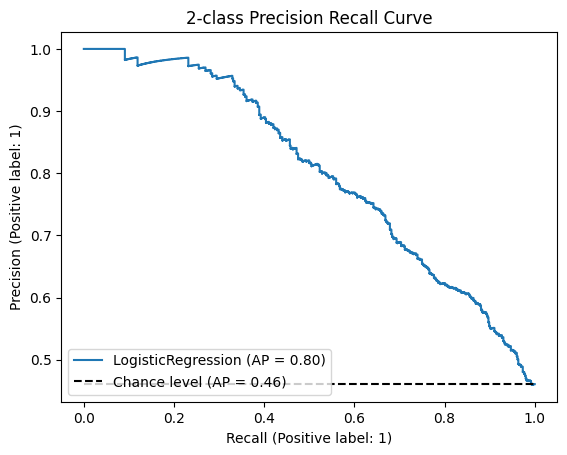

In [15]:
display = PrecisionRecallDisplay.from_estimator(
    lr_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

In [16]:
# Recall on base model
y_train_pred = lr.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = lr_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.743
Recall on Training set (Tune Model): 0.754


### AUC Score

In [17]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.795
AUC: 0.796


### Cohen's Kappa

In [18]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.478
Cohen's Kappa: 0.414


### Confusion matrix

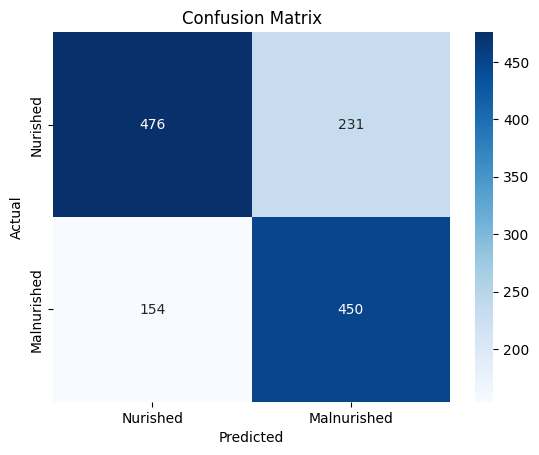

In [19]:
cm = confusion_matrix(y_test, y_pred_tune)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Features importance

In [20]:
# Extract the trained classifier from the pipeline
model = lr_tune.named_steps['clf']

# Get feature names AFTER PolynomialFeatures transformation
feature_names = lr_tune.named_steps['poly'].get_feature_names_out(X_train_sm.columns)

# Get coefficients from the classifier
coefficients = model.coef_[0]  # binary classification

# Create and sort the importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (abs)': np.abs(coefficients)
}).sort_values(by='Importance (abs)', ascending=False)

print(importance_df)


                                               Feature  Coefficient  \
0                                            child_age     0.434420   
15                              child_age child_weight    -0.402265   
21                          child_age health_insurance     0.339070   
1                                         child_weight    -0.298751   
34                       child_weight health_insurance    -0.250280   
..                                                 ...          ...   
53   diarrhoea_last_2_weeks province_Sudoorpaschim ...     0.000000   
52          diarrhoea_last_2_weeks province_Province 5     0.000000   
51          diarrhoea_last_2_weeks province_Province 2     0.000000   
50          diarrhoea_last_2_weeks province_Province 1     0.000000   
119  province_Province 5 province_Sudoorpaschim Pro...     0.000000   

     Importance (abs)  
0            0.434420  
15           0.402265  
21           0.339070  
1            0.298751  
34           0.250280  
.. 

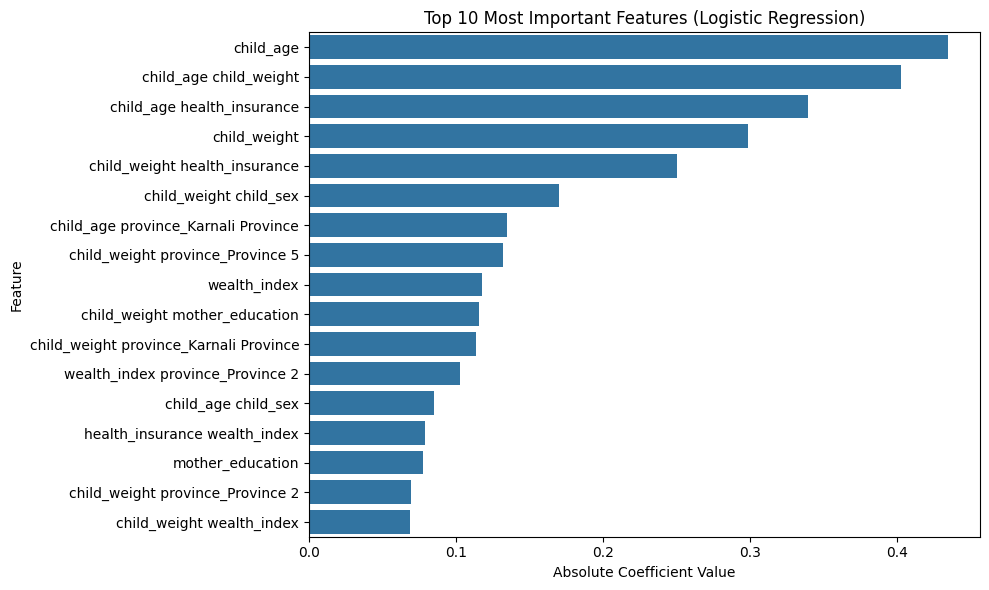

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance (abs)', y='Feature', data=importance_df.head(17))
plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Additional

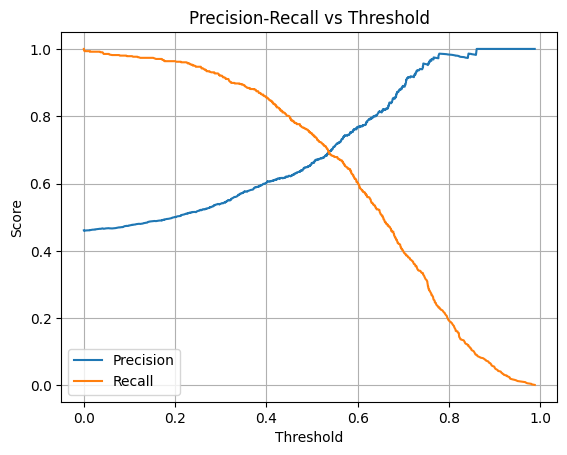

In [22]:
y_probas = lr_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [23]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.52      0.63       707
           1       0.60      0.86      0.71       604

    accuracy                           0.67      1311
   macro avg       0.71      0.69      0.67      1311
weighted avg       0.71      0.67      0.67      1311


